<a href="https://colab.research.google.com/github/madhankumar003/HTIC_Practice_codes/blob/main/Day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Basics of Image**

Image Matrix Shape: (419, 236, 3)


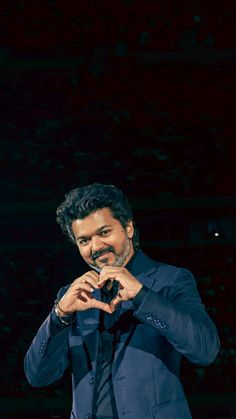

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

image = cv2.imread("my_picture.jpg")

if image is None:
    print("Error: Could not read the image. Check the spelling or file path!")
else:
    print("Image Matrix Shape:", image.shape)

    cv2_imshow(image)



In [ ]:

top_left_pixel = image[0, 0]
print("BGR values at (0,0):", top_left_pixel)

blue_value = image[0, 0, 0]
green_value = image[0, 0, 1]
red_value = image[0, 0, 2]

print("Blue intensity:", blue_value)
print("Green intensity:", green_value)
print("Red intensity:", red_value)


middle_pixel = image[335, 100, 0]
print("BGR values at (200, 100):", middle_pixel)

BGR values at (0,0): [ 0  2 13]
Blue intensity: 0
Green intensity: 2
Red intensity: 13
BGR values at (200, 100): 37


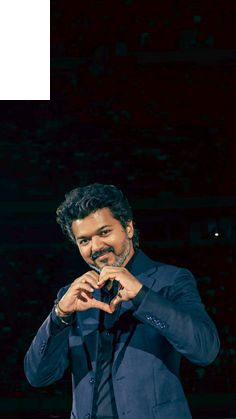

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

image = cv2.imread("my_picture.jpg")

image[0:100, 0:50] = [255, 255, 255]

cv2_imshow(image)

Marked pixel at Row 200, Column 100:


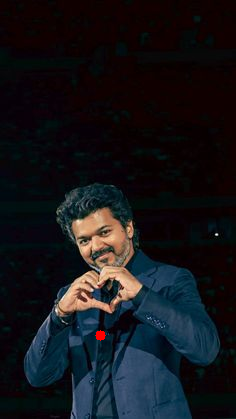

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# 1. Read the image fresh
image = cv2.imread("my_picture.jpg")
cv2.circle(image, (100, 335), radius=5, color=(0, 0, 255), thickness=-1)

print("Marked pixel at Row 200, Column 100:")
cv2_imshow(image)

New Grayscale Matrix Shape: (419, 236)
Grayscale intensity at (0,0): 5
Grayscale intensity at (335,100): 18

Displaying Grayscale Image:


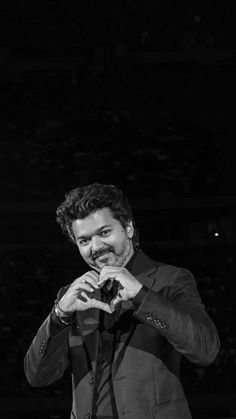

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

image = cv2.imread("my_picture.jpg")

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("New Grayscale Matrix Shape:", gray_image.shape)

pixel_00_gray = gray_image[0, 0]
print("Grayscale intensity at (0,0):", pixel_00_gray)

pixel_middle_gray = gray_image[335, 100]
print("Grayscale intensity at (335,100):", pixel_middle_gray)

print("\nDisplaying Grayscale Image:")
cv2_imshow(gray_image)

Detected shapes using intensity changes:


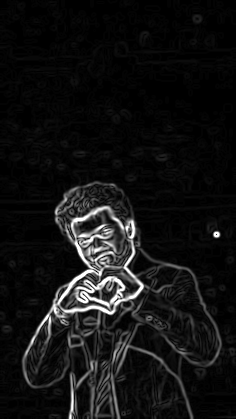

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# 1. Read the image fresh
image = cv2.imread("my_picture.jpg")

# 2. Convert to Grayscale (keep only intensity, drop color)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Step 1 of Pipeline: Apply a Low-Pass Filter (Gaussian Blur)
# This smooths out random pixel static so the edge detector doesn't get confused by noise
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

sobel_x = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

edge_image = cv2.convertScaleAbs(sobel_combined)

# 5. Display the final result showing the detected shapes/edges
print("Detected shapes using intensity changes:")
cv2_imshow(edge_image)

Original Color Image Shape: (419, 236, 3)
Red Channel Matrix Shape: (419, 236)

Displaying ONLY the Red Channel data:


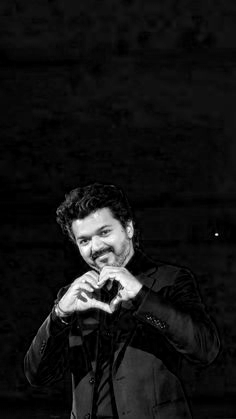

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

image = cv2.imread("my_picture.jpg")

red_channel = image[:, :, 2]

print("Original Color Image Shape:", image.shape)
print("Red Channel Matrix Shape:", red_channel.shape)

print("\nDisplaying ONLY the Red Channel data:")
cv2_imshow(red_channel)

**Gaussian Distribution**

[[0.09474166 0.11831801 0.09474166]
 [0.11831801 0.14776132 0.11831801]
 [0.09474166 0.11831801 0.09474166]]
Image blurred using our scratch-built Gaussian filter:


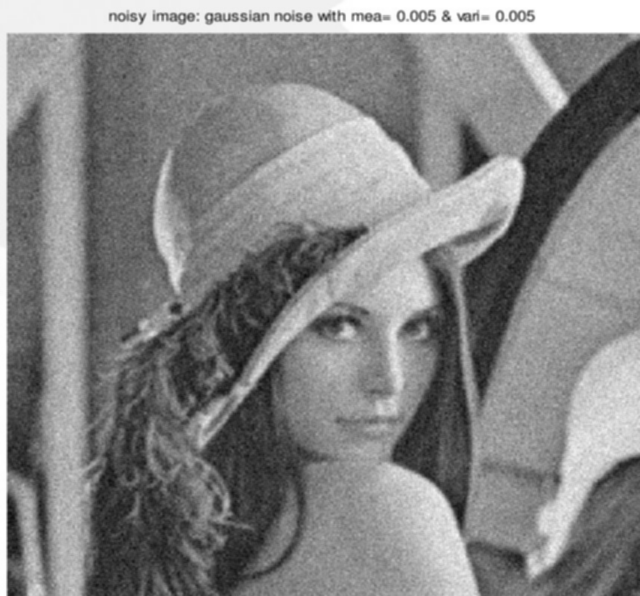

In [ ]:
import numpy as np

import cv2

from google.colab.patches import cv2_imshow



def create_gaussian_kernel(size=3, sigma=1.0):

    """Step 1: Build the Gaussian weight grid from scratch"""

    kernel = np.zeros((size, size), dtype=np.float32)

    k = size // 2



    for x in range(-k, k + 1):

        for y in range(-k, k + 1):

            exponent = -(x**2 + y**2) / (2 * (sigma**2))

            kernel[x + k, y + k] = np.exp(exponent)



    kernel = kernel / np.sum(kernel)
    print(kernel)
    return kernel

#print(create_gaussian_kernel(size=3, sigma=1.0))

def apply_gaussian_blur_from_scratch(image, size=3, sigma=1.0):

    """Step 3: Slide the kernel across the image pixels (Convolution)"""

    h, w = image.shape

    k = size // 2




    output = np.zeros((h, w), dtype=np.float32)

    kernel = create_gaussian_kernel(size, sigma)


    padded_image = np.pad(image, k, mode='edge')


    for i in range(h):

        for j in range(w):

            region = padded_image[i:i + size, j:j + size]



            new_value = np.sum(region * kernel)



            output[i, j] = new_value



    return output.astype(np.uint8)





image = cv2.imread("my_picture2.jpg")

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)



custom_blurred = apply_gaussian_blur_from_scratch(gray_image, size=3, sigma=1.5)




print("Image blurred using our scratch-built Gaussian filter:")

cv2_imshow(custom_blurred)

Image blurred using our scratch-built Gaussian filter:


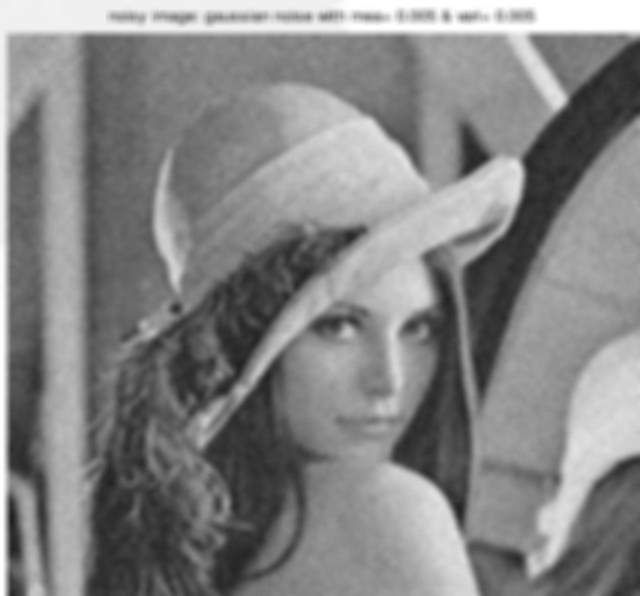

In [ ]:
import numpy as np

import cv2

from google.colab.patches import cv2_imshow



def create_gaussian_kernel(size=3, sigma=1.0):

    """Step 1: Build the Gaussian weight grid from scratch"""

    kernel = np.zeros((size, size), dtype=np.float32)

    k = size // 2

#we start at the -1 index because it will ruin
#after the calculation of the value we insert the value in the correct coordinate


    for x in range(-k, k + 1):

        for y in range(-k, k + 1):


            exponent = -(x**2 + y**2) / (2 * (sigma**2))

            kernel[x + k, y + k] = np.exp(exponent)


#if we did not normalize it will scale up the pixel value
    kernel = kernel / np.sum(kernel)

    return kernel



def apply_gaussian_blur_from_scratch(image, size=3, sigma=1.0):

    """Step 3: Slide the kernel across the image pixels (Convolution)"""

    h, w = image.shape

    k = size // 2




    output = np.zeros((h, w), dtype=np.float32)

    kernel = create_gaussian_kernel(size, sigma)

    #here we did not that complex formulae it write here
    padded_image = np.pad(image, k, mode='edge')
   for i in range(h):

        for j in range(w):
          #the formuale fitts in

            region = padded_image[i:i + size, j:j + size]



            new_value = np.sum(region * kernel)



            output[i, j] = new_value



    return output.astype(np.uint8)





image = cv2.imread("my_picture2.jpg")

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)



custom_blurred = apply_gaussian_blur_from_scratch(gray_image, size=9, sigma=4.0)




print("Image blurred using our scratch-built Gaussian filter:")

cv2_imshow(custom_blurred)